## Exercise - Build and Evaluate a Simple Time Series
Your task is to build simple baseline forecasts for hourly electricity demand and compare which one works best.

Use the `demand` DataFrame, where the target column is `demand`.

Create the following forecast columns:

- `forecast_lag1` — demand from 1 hour ago
- `forecast_lag24` — demand from the same hour yesterday
- `forecast_lag168` — demand from the same hour one week ago
- `forecast_roll24` — average demand from the previous 24 hours

Make sure the rolling forecast only uses past values. Then:


1. Remove rows with missing values;
2. Calculate the mean absolute error (MAE) for each forecast method;
3. Use the first 168 rows of the cleaned baseline DataFrame to plot one week of results.

The plot should include:

- actual demand
- lag 1 forecast
- lag 24 forecast
- lag 168 forecast
- rolling 24h forecast


---

### Questions

Answer the following questions:

1. How many rows remain after removing missing values?
2. What is the MAE for `forecast_lag1`?
3. What is the MAE for `forecast_lag24`?
4. What is the MAE for `forecast_lag168`?
5. What is the MAE for `forecast_roll24`?
6. What does the best-performing baseline tell us about the time series pattern?

### Answers

1. 8592 rows remain after removing missing values.
2. The MAE for forecast_lag1 is approximately 33.86.
3. The MAE for forecast_lag24 is approximately 58.95.
4. The MAE for forecast_lag168 is approximately 58.01.
5. The MAE for forecast_roll24 is approximately 111.65.
6. The best-peforming baseline is forecast_lag1, which suggests that the electricity demand series has strong short-term persistence - the demand value from the previous hour is the most useful estimate for the current hour, demand gradually changes from one hour to the next.

In [1]:
# Imports
import datetime
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns



from sklearn.metrics import mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR,LinearSVR


import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.deterministic import DeterministicProcess
from statsmodels.tsa.seasonal import seasonal_decompose


import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Preassemble to match existing lab materials
elering = pd.read_csv('../data/electricity-production and consumption_2022.csv',  delimiter=';',decimal=',')
elering['timestamp'] = pd.to_datetime(elering['Kuupaev (Eesti aeg)'], dayfirst=True)

demand = elering[['timestamp', 'Tarbimine']]
demand.set_index('timestamp', inplace=True)
demand = demand.rename(columns = {'Tarbimine':'demand'})

In [3]:
baseline = demand[["demand"]].copy()

baseline["forecast_lag1"] = baseline["demand"].shift(1)
baseline["forecast_lag24"] = baseline["demand"].shift(24)
baseline["forecast_lag168"] = baseline["demand"].shift(168)

baseline["forecast_roll24"] = (
    baseline["demand"]
    .shift(1)
    .rolling(24)
    .mean()
)

baseline = baseline.dropna()

In [4]:
mae_lag1 = (baseline["demand"] - baseline["forecast_lag1"]).abs().mean()
mae_lag24 = (baseline["demand"] - baseline["forecast_lag24"]).abs().mean()
mae_lag168 = (baseline["demand"] - baseline["forecast_lag168"]).abs().mean()
mae_roll24 = (baseline["demand"] - baseline["forecast_roll24"]).abs().mean()

print("Rows after removing missing values:", len(baseline))
print("MAE lag1:", mae_lag1)
print("MAE lag24:", mae_lag24)
print("MAE lag168:", mae_lag168)
print("MAE roll24:", mae_roll24)

Rows after removing missing values: 8592
MAE lag1: 33.86336126629423
MAE lag24: 58.948486964618255
MAE lag168: 58.01077746741155
MAE roll24: 111.64626299658597


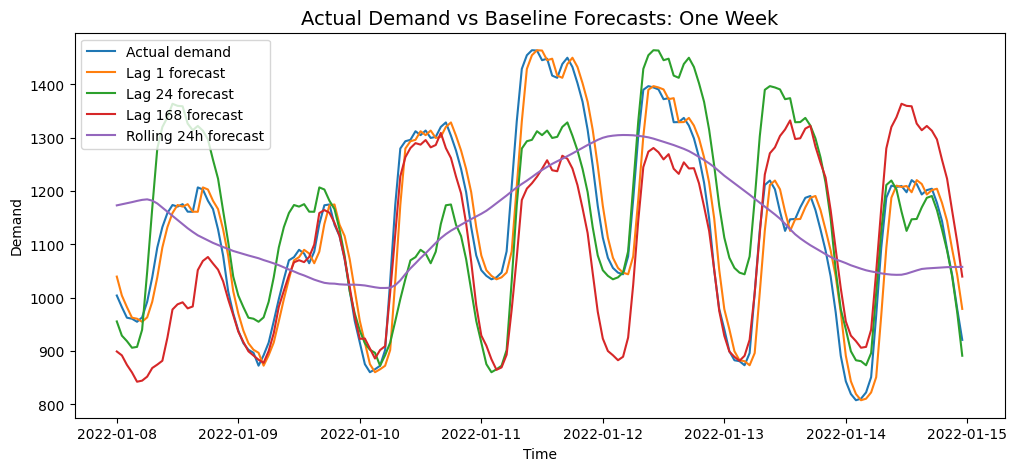

In [10]:
plot_data = baseline.iloc[:168]

plt.figure(figsize=(12, 5))

plt.plot(plot_data.index, plot_data["demand"], label="Actual demand")
plt.plot(plot_data.index, plot_data["forecast_lag1"], label="Lag 1 forecast")
plt.plot(plot_data.index, plot_data["forecast_lag24"], label="Lag 24 forecast")
plt.plot(plot_data.index, plot_data["forecast_lag168"], label="Lag 168 forecast")
plt.plot(plot_data.index, plot_data["forecast_roll24"], label="Rolling 24h forecast")

plt.title("Actual Demand vs Baseline Forecasts: One Week", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Demand")
plt.legend()
plt.show()